# 🩺 Breast Cancer Classification — A Comparative Study of ML Algorithms

**Goal:** Predict whether a breast tumor is **malignant** or **benign** using the
Wisconsin Breast Cancer diagnostic dataset (built into scikit-learn), while comparing
several classification algorithms on the same data.

**What this notebook covers**
1. Exploratory Data Analysis (EDA) & visualization
2. Data preprocessing (scaling, train/test split)
3. Training & tuning 7 classification models
4. Model evaluation with confusion matrices & classification reports
5. Side-by-side model comparison
6. A theory section for each algorithm — how it works, how it minimizes error
   (gradient descent vs. other optimization strategies), and an **interview
   cheat-sheet** summarizing the key facts recruiters commonly ask about.

---


## 1. 📦 Imports & Setup

In [1]:
# --- Core libraries ---
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preprocessing & model selection ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# --- Metrics ---
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
)

# --- Plot style / reproducibility ---
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 2. 📂 Load & Prepare the Dataset

We use `load_breast_cancer()` from scikit-learn — 569 samples, 30 numeric features
derived from digitized images of breast masses (radius, texture, perimeter, area,
smoothness, etc.), with a binary target: `0 = malignant`, `1 = benign`.

In [2]:
data = load_breast_cancer()

df = pd.DataFrame(data=data.data, columns=data.feature_names)
df["target"] = data.target.astype(int)

print(f"Shape: {df.shape}")
print(f"Classes: {dict(zip(data.target_names, range(len(data.target_names))))}")
df.head()


Shape: (569, 31)
Classes: {np.str_('malignant'): 0, np.str_('benign'): 1}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2.1 Dataset structure & data types

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
df.describe().T.style.background_gradient(cmap="Blues")


,count,mean,std,min,25%,50%,75%,max
mean radius,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
mean texture,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
mean perimeter,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
mean area,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
mean smoothness,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
mean compactness,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
mean concavity,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
mean concave points,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
mean symmetry,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
mean fractal dimension,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


### 2.2 Data quality checks — missing values & duplicates

In [5]:
print("Missing values per column:\n", df.isnull().sum().sum(), "total missing values")
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
 0 total missing values
Duplicate rows: 0


## 3. 🔎 Exploratory Data Analysis (EDA)

We explore class balance, feature distributions, outliers, and correlations before
modeling — this drives decisions like scaling and helps spot redundant / highly
correlated features.

### 3.1 Target class balance

target
Benign (1)       357
Malignant (0)    212
Name: count, dtype: int64


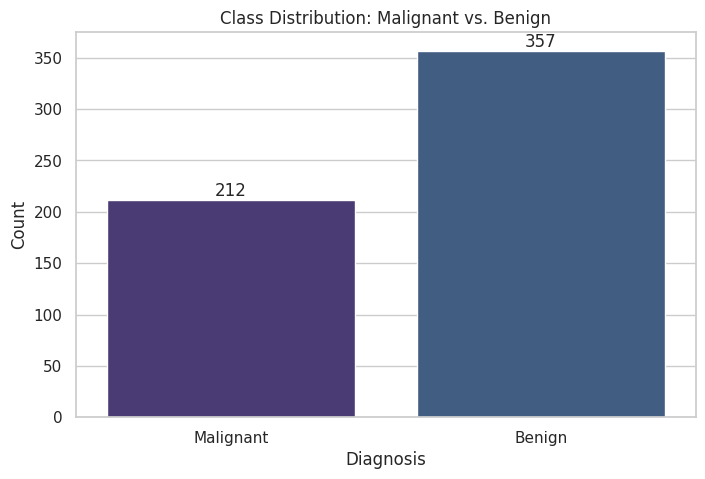

In [6]:
target_counts = df["target"].value_counts().rename(index={0: "Malignant (0)", 1: "Benign (1)"})
print(target_counts)

fig, ax = plt.subplots()
sns.countplot(x=df["target"].map({0: "Malignant", 1: "Benign"}), hue=df["target"].map({0: "Malignant", 1: "Benign"}), legend=False, ax=ax)
ax.set_title("Class Distribution: Malignant vs. Benign")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


> **Why this matters:** the classes are moderately imbalanced (~63% / 37%).
> This is not extreme, but it's still worth reporting **precision/recall/F1 per
> class** rather than relying on accuracy alone (see the Confusion Matrix &
> Classification Report section below).

### 3.2 Feature distributions by class (selected features)

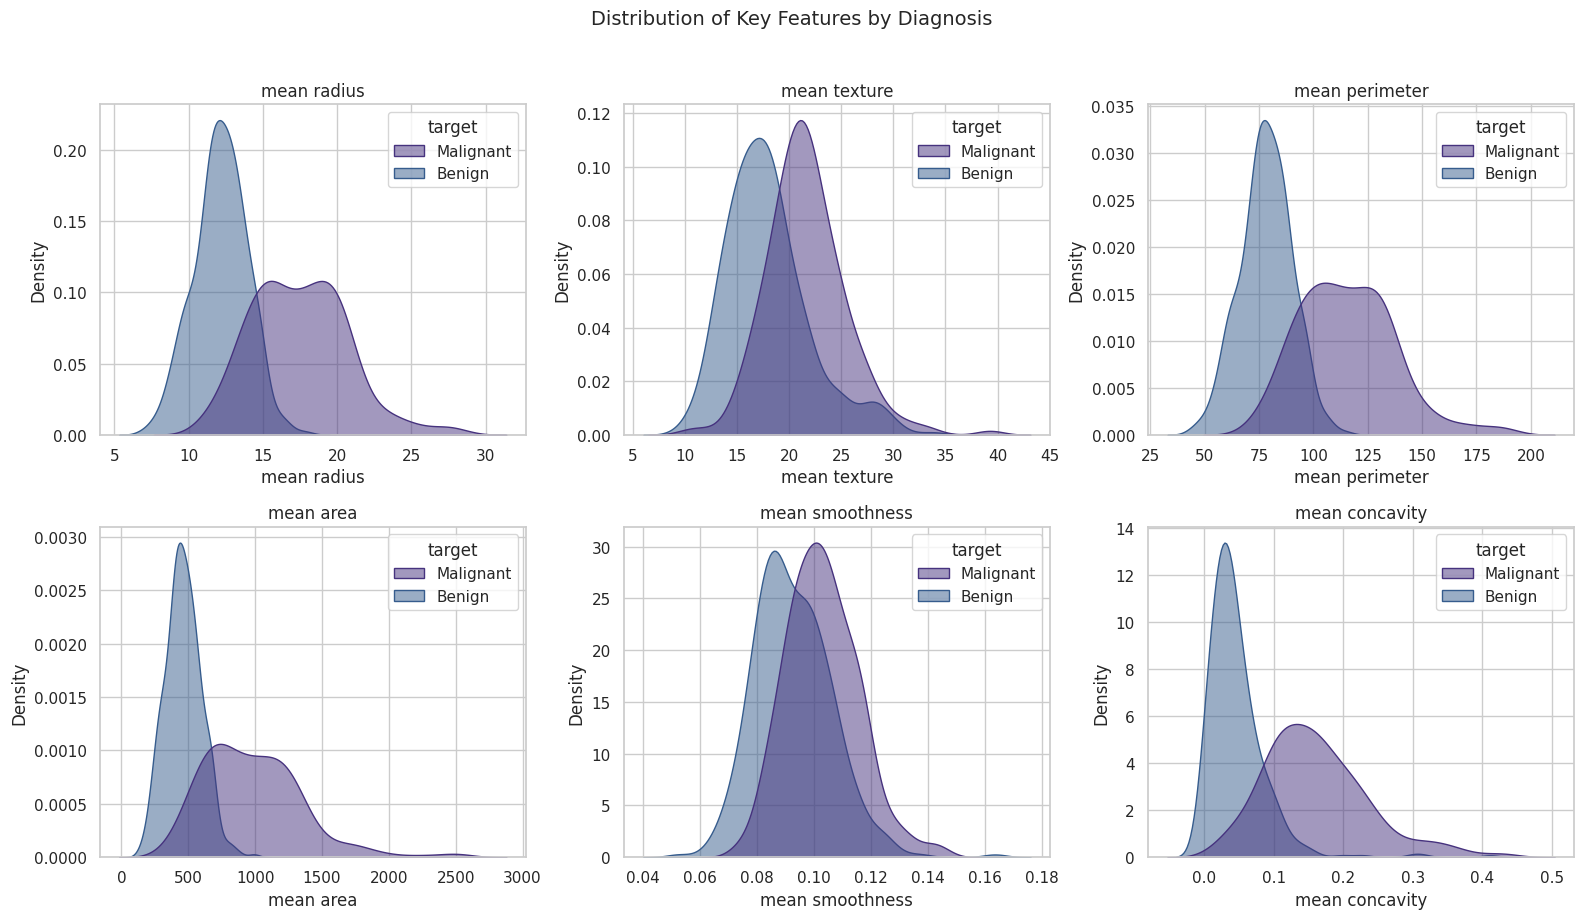

In [7]:
key_features = ["mean radius", "mean texture", "mean perimeter", "mean area",
                 "mean smoothness", "mean concavity"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.ravel(), key_features):
    sns.kdeplot(data=df, x=feat, hue=df["target"].map({0: "Malignant", 1: "Benign"}),
                fill=True, common_norm=False, alpha=0.5, ax=ax)
    ax.set_title(feat)
plt.suptitle("Distribution of Key Features by Diagnosis", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 3.3 Outlier detection (boxplots)

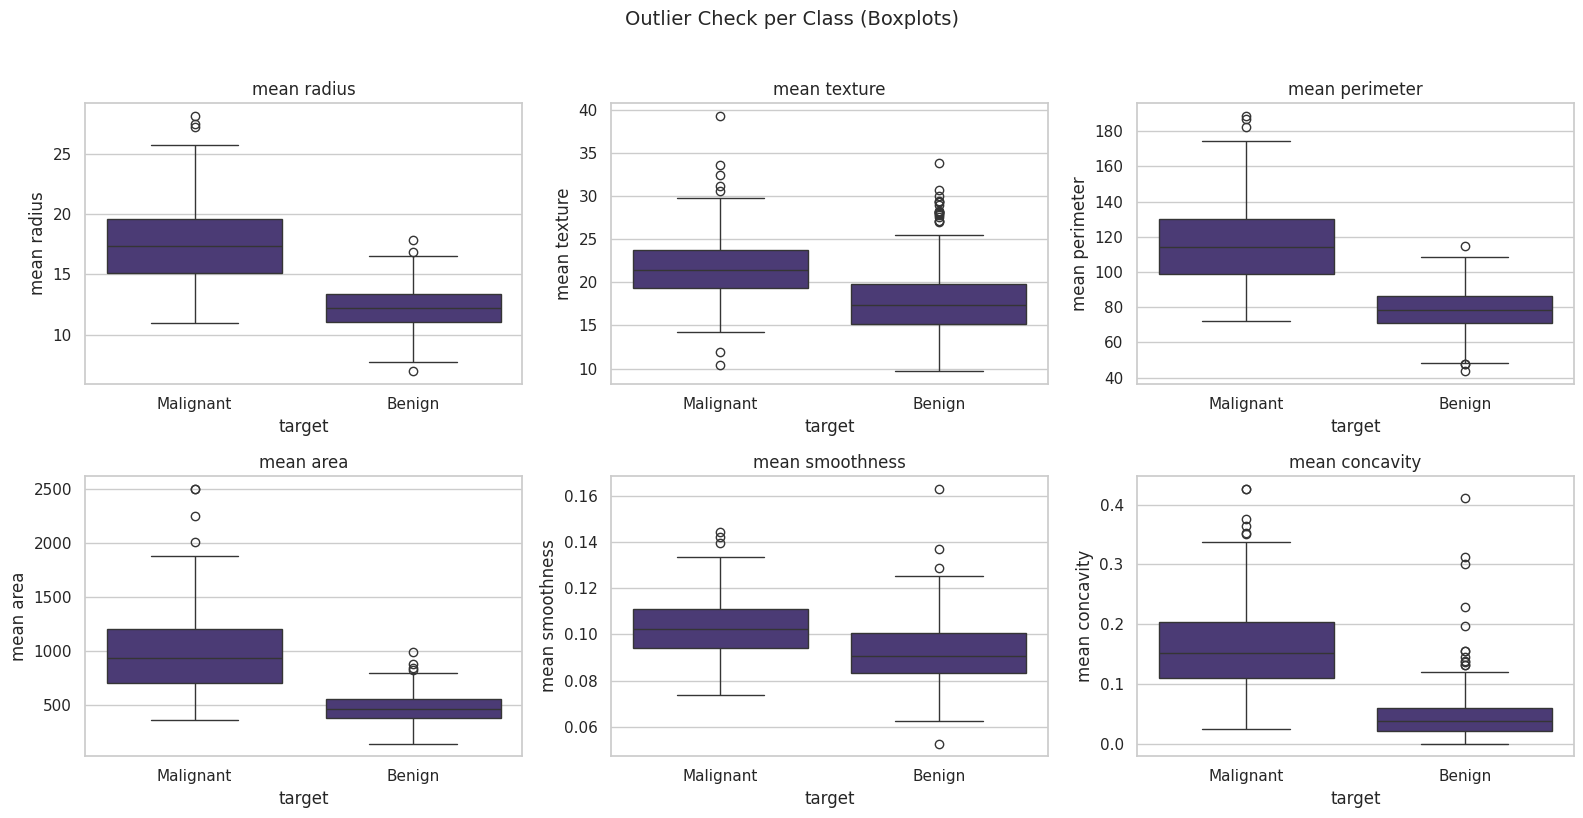

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, feat in zip(axes.ravel(), key_features):
    sns.boxplot(data=df, x=df["target"].map({0: "Malignant", 1: "Benign"}), y=feat, ax=ax)
    ax.set_title(feat)
plt.suptitle("Outlier Check per Class (Boxplots)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### 3.4 Pairwise relationships (subset of features)

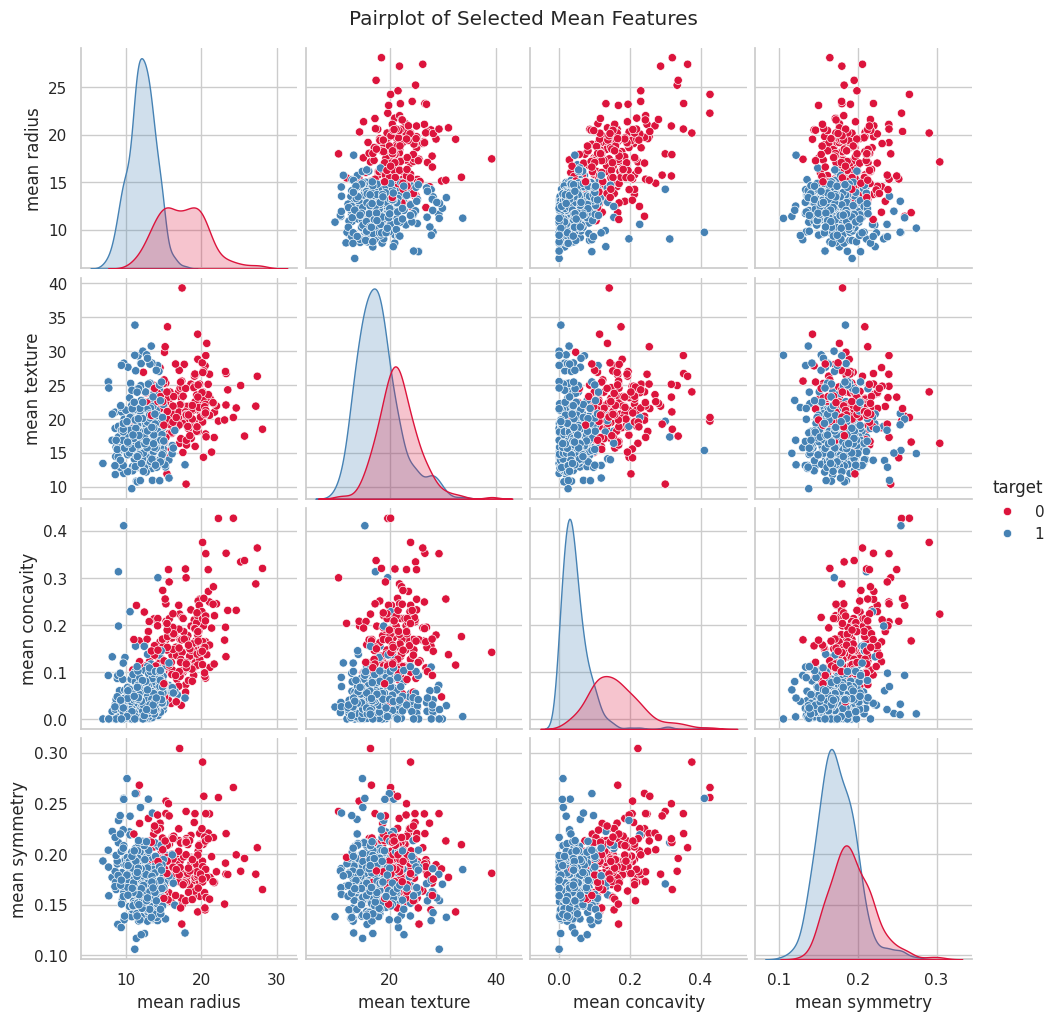

In [9]:
subset_cols = ["mean radius", "mean texture", "mean concavity", "mean symmetry", "target"]
sns.pairplot(df[subset_cols], hue="target", palette={0: "crimson", 1: "steelblue"}, diag_kind="kde")
plt.suptitle("Pairplot of Selected Mean Features", y=1.02)
plt.show()


> **Note:** we deliberately plot only a handful of the 30 features here — a full
> 30x30 pairplot is expensive to render and hard to read. Use the correlation
> heatmap below to explore relationships across *all* features at once.

### 3.5 Correlation heatmap (all features)

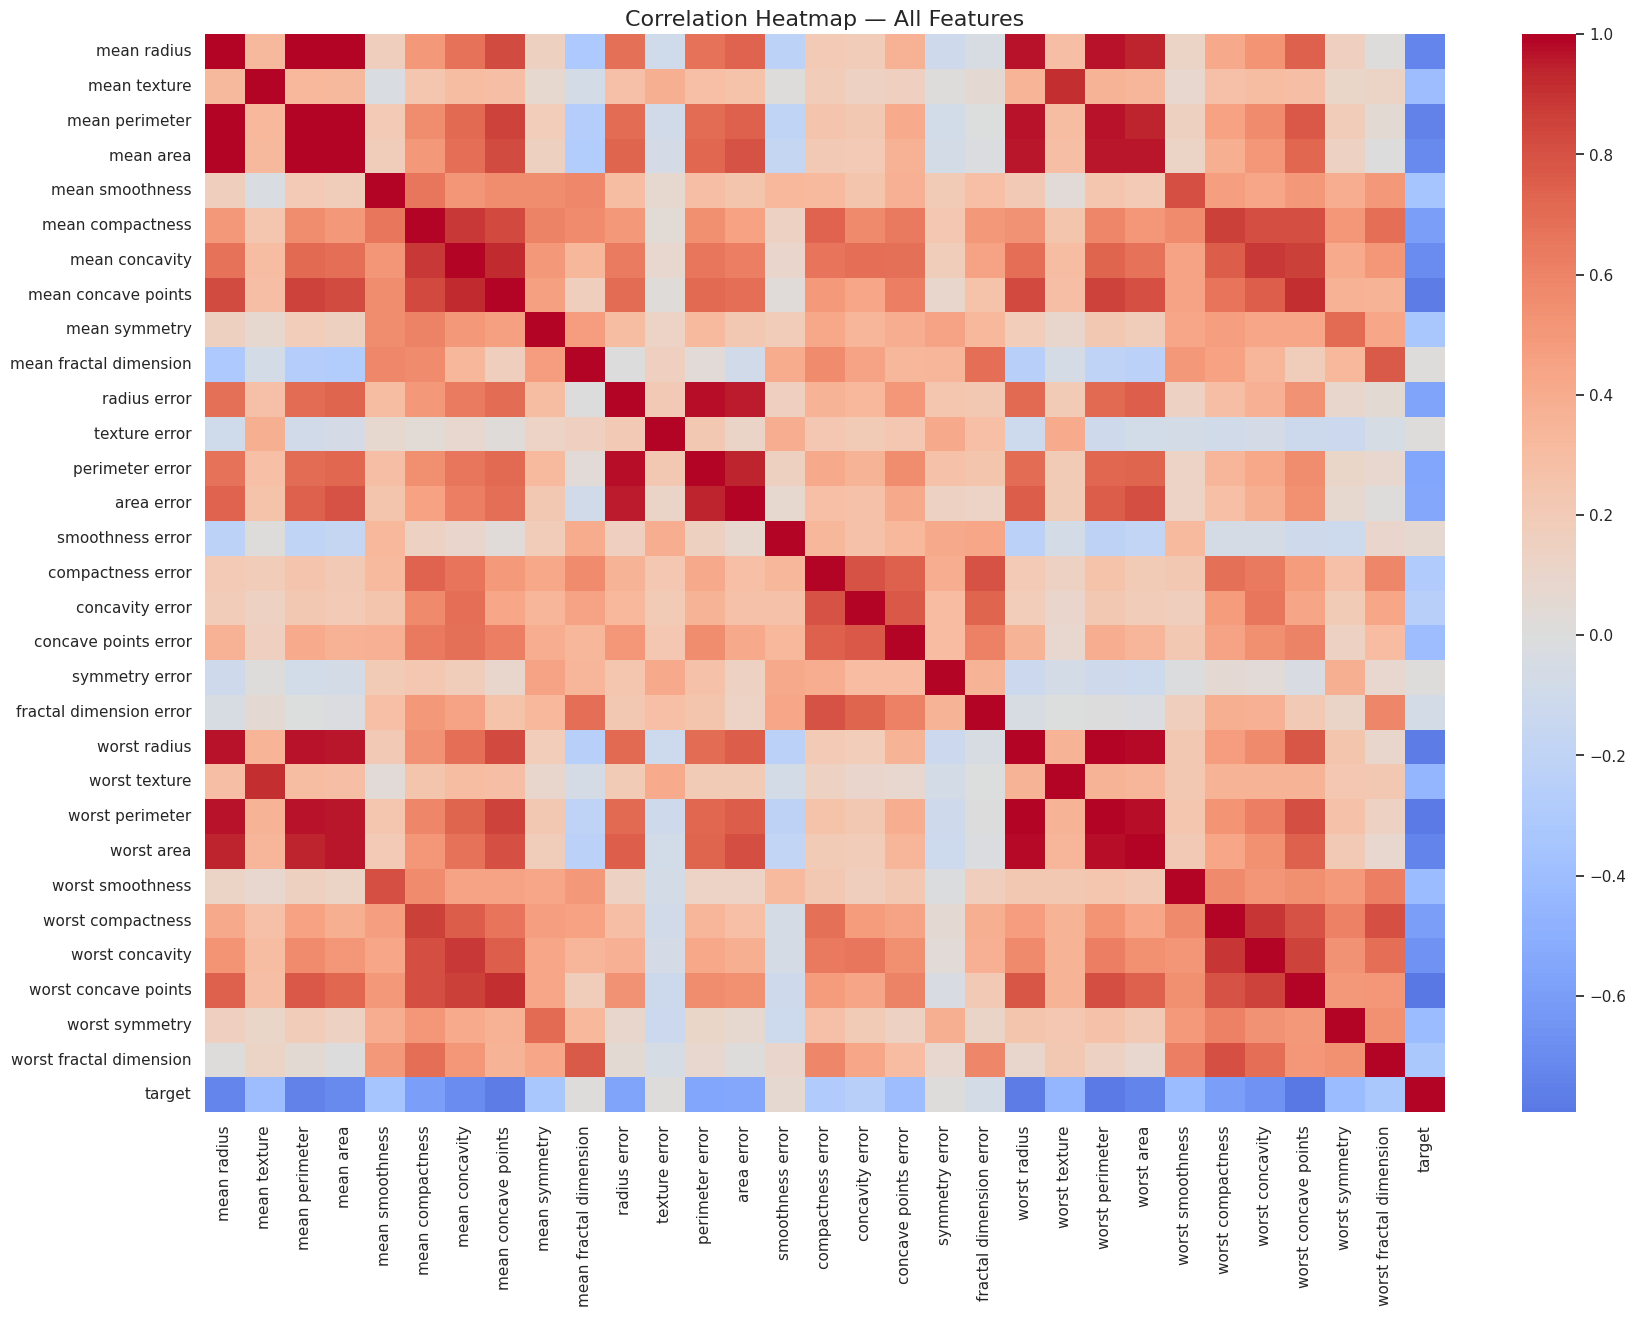

Top 10 features most correlated with target:
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
worst area             -0.733825
mean radius            -0.730029
mean area              -0.708984
mean concavity         -0.696360
worst concavity        -0.659610
Name: target, dtype: float64


In [10]:
plt.figure(figsize=(20, 14))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — All Features", fontsize=16)
plt.show()

# Features most correlated with the target
corr_with_target = df.corr()["target"].drop("target").sort_values(key=abs, ascending=False)
print("Top 10 features most correlated with target:")
print(corr_with_target.head(10))


> **Why this matters:** several features (e.g. `mean radius`, `mean perimeter`,
> `mean area`) are extremely correlated with each other (they're geometrically
> related) — this **multicollinearity** doesn't hurt tree-based models much, but
> it can affect the stability of linear models' coefficients. It also tells us
> which features are most predictive of the diagnosis.

## 4. ⚙️ Preprocessing

**Steps:**
1. Split features (`X`) from target (`y`)
2. Train/test split (80/20), **stratified** on the target to preserve class balance
3. **Standardize** features — critical for distance-based and gradient-based models
   (KNN, SVM, Logistic Regression) since raw features are on very different scales
   (e.g. `mean area` ~ hundreds vs `mean smoothness` ~ 0.1).

In [11]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")


Train shape: (455, 30), Test shape: (114, 30)


> **`StandardScaler` vs `MinMaxScaler`:** `StandardScaler` (z-score
> normalization: mean 0, std 1) is generally preferred over min-max scaling for
> models sensitive to outliers or that assume roughly-Gaussian-scaled input
> (Logistic Regression, SVM, KNN, PCA). We fit the scaler **only on the training
> set** and apply it to the test set to avoid data leakage.

## 5. 🤖 Model Training & Evaluation

For every model we will:
1. Briefly explain **how the algorithm works** and **how it minimizes its error**
   (gradient descent, closed-form solution, greedy splitting, etc.)
2. Train it (with hyperparameter tuning via `GridSearchCV` where relevant)
3. Evaluate it with a confusion matrix + classification report
4. Summarize the **interview-ready facts** about it

A results dictionary collects metrics from every model for a final comparison.

In [12]:
results = {}

def evaluate_model(name, model, X_te, y_te, y_pred):
    """Store metrics and plot confusion matrix for a fitted model's predictions."""
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

    print(f"===== {name} =====")
    print(classification_report(y_te, y_pred, target_names=["Malignant", "Benign"]))

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Malignant", "Benign"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.show()


### 5.1 Logistic Regression

**How it works:** models the probability that a sample belongs to class 1 using
the sigmoid function applied to a linear combination of features:
`P(y=1|x) = sigmoid(w·x + b)`.

**How it minimizes error:** minimizes the **log-loss (binary cross-entropy)**
using an iterative optimizer — by default scikit-learn's `lbfgs` solver (a
quasi-Newton method), but it can also be trained with plain **gradient descent** /
**stochastic gradient descent**, iteratively nudging the weights in the direction
that reduces the loss.

**Interview cheat-sheet**
- Type: linear model, discriminative, parametric
- Loss function: log-loss / binary cross-entropy
- Optimizer: gradient-based (lbfgs, SGD, Newton-CG...)
- Assumes: linear decision boundary in feature space (or transformed space)
- Regularization: L1 (Lasso) / L2 (Ridge) via `C` parameter (inverse strength)
- Pros: fast, interpretable coefficients, gives probabilities, works well when
  classes are linearly separable
- Cons: struggles with non-linear boundaries, sensitive to outliers/multicollinearity

===== Logistic Regression =====
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



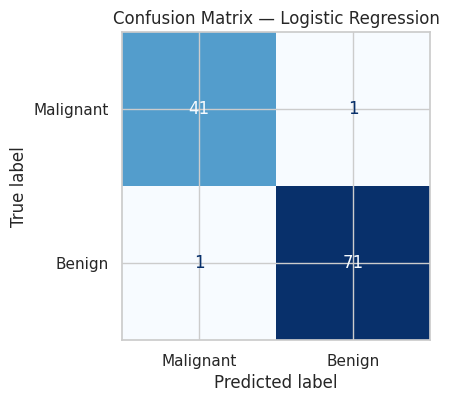

In [13]:
log_reg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test, y_pred_lr)


### 5.2 K-Nearest Neighbors (KNN)

**How it works:** a *lazy, instance-based* learner — it memorizes the training
data and classifies a new point by majority vote among its `k` nearest neighbors
(by distance, usually Euclidean).

**How it minimizes error:** there is **no training-time optimization / no loss
function to minimize** — all the "work" happens at prediction time. Error is
controlled indirectly by choosing `k` (bias-variance trade-off) via
cross-validation / grid search.

**Interview cheat-sheet**
- Type: non-parametric, instance-based, lazy learner
- No explicit training phase (no gradient descent)
- Requires feature scaling (distance-based)
- Key hyperparameter: `k` (number of neighbors) — small k → low bias/high
  variance (overfits), large k → high bias/low variance (underfits)
- Pros: simple, no assumptions about data distribution, naturally multi-class
- Cons: slow prediction on large datasets, sensitive to irrelevant features and
  the curse of dimensionality

Best KNN params: {'n_neighbors': 3, 'weights': 'uniform'}
===== K-Nearest Neighbors =====
              precision    recall  f1-score   support

   Malignant       1.00      0.95      0.98        42
      Benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



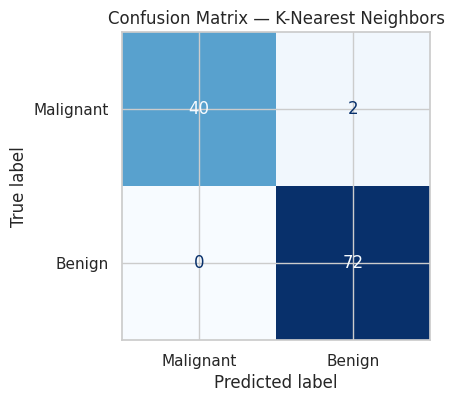

In [14]:
param_grid_knn = {"n_neighbors": list(range(3, 21, 2)), "weights": ["uniform", "distance"]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring="f1")
grid_knn.fit(X_train_scaled, y_train)
print("Best KNN params:", grid_knn.best_params_)

y_pred_knn = grid_knn.predict(X_test_scaled)
evaluate_model("K-Nearest Neighbors", grid_knn, X_test_scaled, y_test, y_pred_knn)


### 5.3 Support Vector Machine (SVM)

**How it works:** finds the hyperplane that maximizes the margin between the two
classes. With the **kernel trick** (e.g. RBF kernel), it can find non-linear
decision boundaries by implicitly mapping data into a higher-dimensional space.

**How it minimizes error:** minimizes **hinge loss** plus an L2 regularization
term (maximize margin ⇄ minimize `‖w‖²`). This is a **convex quadratic
optimization problem**, typically solved with **Sequential Minimal Optimization
(SMO)** rather than plain gradient descent — SMO breaks the QP problem into a
series of smallest-possible 2-variable sub-problems solved analytically.

**Interview cheat-sheet**
- Type: max-margin classifier, kernel method
- Loss function: hinge loss
- Optimizer: quadratic programming (SMO), not gradient descent
- Key hyperparameters: `C` (regularization / margin softness), `gamma` (RBF
  kernel reach), `kernel` (linear, rbf, poly...)
- Pros: effective in high-dimensional space, robust to overfitting with the
  right `C`, works well when there's a clear margin of separation
- Cons: slow to train on large datasets, less interpretable, needs careful
  tuning of `C`/`gamma`

Best SVM params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
===== Support Vector Machine =====
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



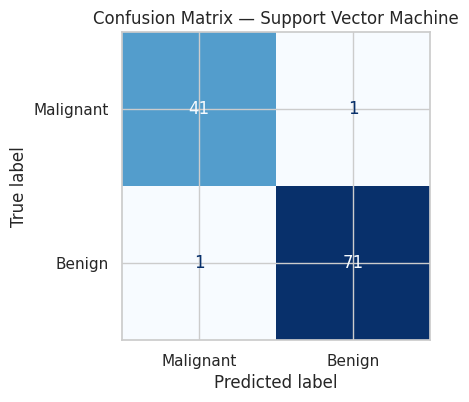

In [15]:
param_grid_svm = {"C": [0.1, 1, 10, 100], "gamma": [1, 0.1, 0.01, 0.001], "kernel": ["rbf"]}
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring="f1")
grid_svm.fit(X_train_scaled, y_train)
print("Best SVM params:", grid_svm.best_params_)

y_pred_svm = grid_svm.predict(X_test_scaled)
evaluate_model("Support Vector Machine", grid_svm, X_test_scaled, y_test, y_pred_svm)


### 5.4 Decision Tree

**How it works:** recursively splits the feature space into regions using
if/else rules on individual features, forming a tree of decisions ending in
leaf nodes that predict a class.

**How it minimizes error:** uses a **greedy, recursive splitting algorithm**
(CART) — at each node it picks the feature/threshold that most reduces
**Gini impurity** (or entropy/information gain), not gradient descent. It's a
greedy heuristic, not a global optimizer, so trees are prone to overfitting
without constraints (max depth, min samples per leaf).

**Interview cheat-sheet**
- Type: non-parametric, rule-based
- Splitting criteria: Gini impurity or entropy (information gain)
- Optimizer: greedy recursive partitioning (CART algorithm), not gradient-based
- Pros: highly interpretable, no scaling needed, handles non-linear relationships
- Cons: prone to overfitting, unstable (small data changes → different tree),
  usually outperformed by ensembles

Best Decision Tree params: {'max_depth': 5, 'min_samples_split': 5}
===== Decision Tree =====
              precision    recall  f1-score   support

   Malignant       0.87      0.93      0.90        42
      Benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



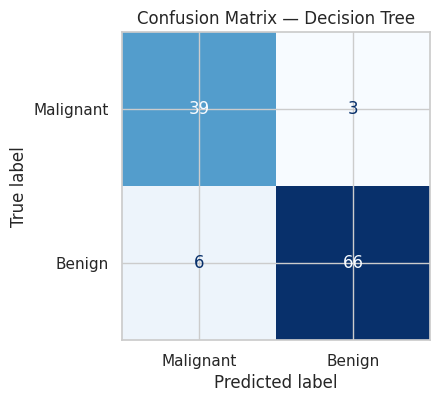

In [16]:
param_grid_dt = {"max_depth": [3, 5, 7, 10, None], "min_samples_split": [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid_dt, cv=5, scoring="f1")
grid_dt.fit(X_train_scaled, y_train)
print("Best Decision Tree params:", grid_dt.best_params_)

y_pred_dt = grid_dt.predict(X_test_scaled)
evaluate_model("Decision Tree", grid_dt, X_test_scaled, y_test, y_pred_dt)


### 5.5 Random Forest

**How it works:** an **ensemble (bagging)** of many decision trees, each trained
on a bootstrap sample of the data with a random subset of features considered at
each split; the final prediction is a majority vote across trees.

**How it minimizes error:** each individual tree still minimizes Gini
impurity/entropy greedily, but the ensemble reduces **variance** (not via
gradient descent) by averaging many decorrelated trees — this is the core idea
of **bagging (Bootstrap Aggregating)**.

**Interview cheat-sheet**
- Type: ensemble, bagging
- Base learner: decision trees
- Reduces variance via bootstrap sampling + random feature subsets
- Optimizer: none globally — greedy splits per tree + averaging
- Pros: strong accuracy out-of-the-box, robust to overfitting vs. single trees,
  gives feature importances
- Cons: less interpretable than a single tree, larger memory/compute footprint

Best Random Forest params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
===== Random Forest =====
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



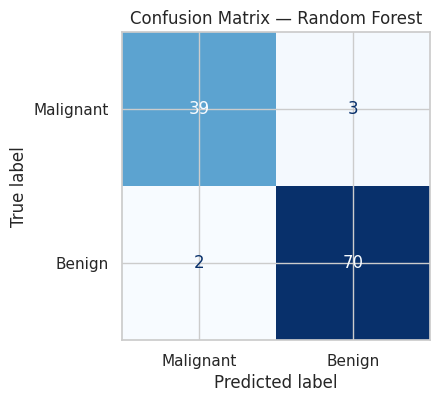

In [17]:
param_grid_rf = {"n_estimators": [100, 200], "max_depth": [None, 5, 10], "min_samples_split": [2, 5]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), param_grid_rf, cv=5, scoring="f1")
grid_rf.fit(X_train_scaled, y_train)
print("Best Random Forest params:", grid_rf.best_params_)

y_pred_rf = grid_rf.predict(X_test_scaled)
evaluate_model("Random Forest", grid_rf, X_test_scaled, y_test, y_pred_rf)


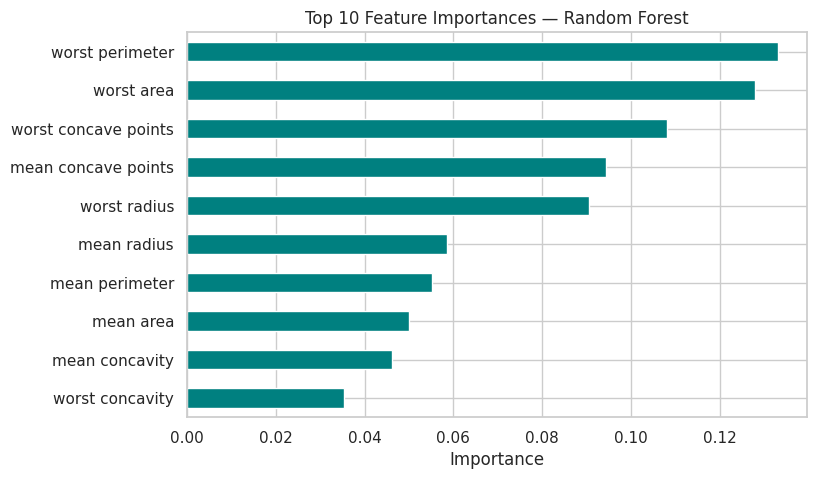

In [18]:
# Feature importance from the tuned Random Forest
importances = pd.Series(grid_rf.best_estimator_.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh", figsize=(8, 5), color="teal")
plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


### 5.6 Gradient Boosting

**How it works:** an **ensemble (boosting)** method that builds trees
*sequentially*, where each new tree is trained to correct the errors
(residuals) of the combined ensemble so far.

**How it minimizes error:** this is the algorithm most literally named after
**gradient descent** — but it performs **gradient descent in function space**:
each new tree is fit to the negative gradient of the loss function with respect
to the current ensemble's predictions, and predictions are updated as
`F(x) += learning_rate * new_tree(x)`.

**Interview cheat-sheet**
- Type: ensemble, boosting (sequential, not parallel like Random Forest)
- Optimizer: gradient descent in function space (fits trees to pseudo-residuals)
- Key hyperparameters: `n_estimators`, `learning_rate`, `max_depth`
- Pros: often top accuracy on tabular data, flexible loss functions
- Cons: slower to train (sequential), more sensitive to hyperparameters, can
  overfit if `n_estimators` too high / `learning_rate` too high

Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
===== Gradient Boosting =====
              precision    recall  f1-score   support

   Malignant       0.95      0.90      0.93        42
      Benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



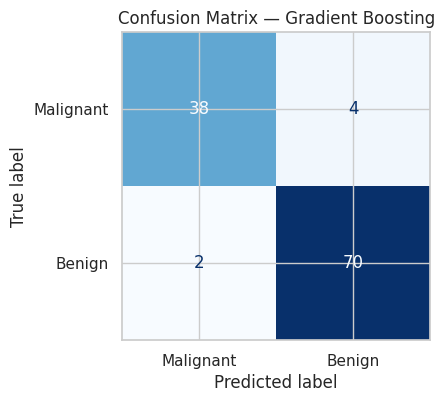

In [19]:
param_grid_gb = {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [2, 3]}
grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), param_grid_gb, cv=5, scoring="f1")
grid_gb.fit(X_train_scaled, y_train)
print("Best Gradient Boosting params:", grid_gb.best_params_)

y_pred_gb = grid_gb.predict(X_test_scaled)
evaluate_model("Gradient Boosting", grid_gb, X_test_scaled, y_test, y_pred_gb)


### 5.7 Gaussian Naive Bayes

**How it works:** applies Bayes' theorem with a "naive" assumption that all
features are **conditionally independent** given the class; for continuous
features it models each feature's distribution per class as Gaussian.

**How it minimizes error:** there is **no iterative optimization / gradient
descent** — parameters (per-class mean and variance for each feature) are
estimated directly via **Maximum Likelihood Estimation (MLE)** in closed form.

**Interview cheat-sheet**
- Type: probabilistic, generative model
- Optimizer: closed-form MLE, not gradient-based, extremely fast to train
- Key assumption: feature independence given the class (often violated in
  practice, yet the model still performs surprisingly well)
- Pros: very fast, works well with small data, naturally handles multi-class
- Cons: the independence assumption can hurt accuracy when features are
  correlated (as we saw in the correlation heatmap!)

===== Gaussian Naive Bayes =====
              precision    recall  f1-score   support

   Malignant       0.90      0.90      0.90        42
      Benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



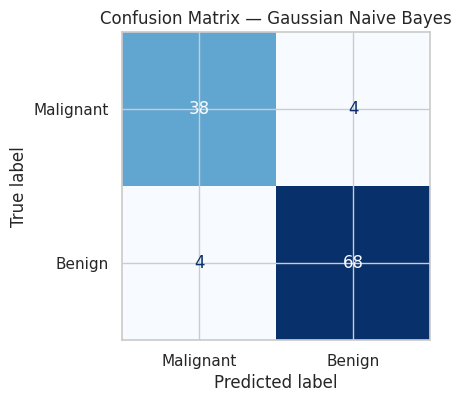

In [20]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
evaluate_model("Gaussian Naive Bayes", nb_model, X_test_scaled, y_test, y_pred_nb)


## 6. 📊 Understanding the Confusion Matrix & Classification Report

### Confusion Matrix

|                     | Predicted Malignant | Predicted Benign |
|---------------------|:-------------------:|:-----------------:|
| **Actual Malignant**| True Negative (TN)* | False Positive (FP) |
| **Actual Benign**   | False Negative (FN)*| True Positive (TP) |

*(labels flip depending on which class you call "positive" — in this dataset
`1 = benign` is treated as the positive class by scikit-learn's default.)*

- **True Positive (TP):** correctly predicted benign
- **True Negative (TN):** correctly predicted malignant
- **False Positive (FP):** predicted benign, but actually malignant → **dangerous
  in medical contexts** (a missed cancer diagnosis)
- **False Negative (FN):** predicted malignant, but actually benign → causes
  unnecessary worry/treatment, but less dangerous than FP here

### Classification Report — key metrics

- **Precision** = `TP / (TP + FP)` — of all predicted positives, how many were
  actually positive? ("How trustworthy are positive predictions?")
- **Recall (Sensitivity)** = `TP / (TP + FN)` — of all actual positives, how
  many did we catch? ("How many did we miss?") — **critical in cancer
  detection**, since missing a malignant case (false negative for malignant) can
  be life-threatening.
- **F1-score** = harmonic mean of precision and recall — balances both,
  useful when classes are imbalanced.
- **Support** = number of true instances of each class in the test set.
- **Accuracy** = overall fraction of correct predictions — can be misleading
  on imbalanced datasets.
- **Macro avg** = unweighted mean across classes (treats classes equally).
- **Weighted avg** = mean weighted by class support (accounts for imbalance).

> **Interview tip:** be ready to explain *why accuracy alone is insufficient*
> for imbalanced or high-stakes classification problems (like this one), and
> why recall on the malignant class matters more here than raw accuracy.

## 7. 🏁 Model Comparison

Side-by-side comparison of all tuned models on the held-out test set.

In [21]:
results_df = pd.DataFrame(results).T.sort_values("F1-score", ascending=False)
results_df.style.background_gradient(cmap="Greens", axis=0).format("{:.4f}")


,Accuracy,Precision,Recall,F1-score
K-Nearest Neighbors,0.9825,0.9730,1.0000,0.9863
Logistic Regression,0.9825,0.9861,0.9861,0.9861
Support Vector Machine,0.9825,0.9861,0.9861,0.9861
Random Forest,0.9561,0.9589,0.9722,0.9655
Gradient Boosting,0.9474,0.9459,0.9722,0.9589
Gaussian Naive Bayes,0.9298,0.9444,0.9444,0.9444
Decision Tree,0.9211,0.9565,0.9167,0.9362


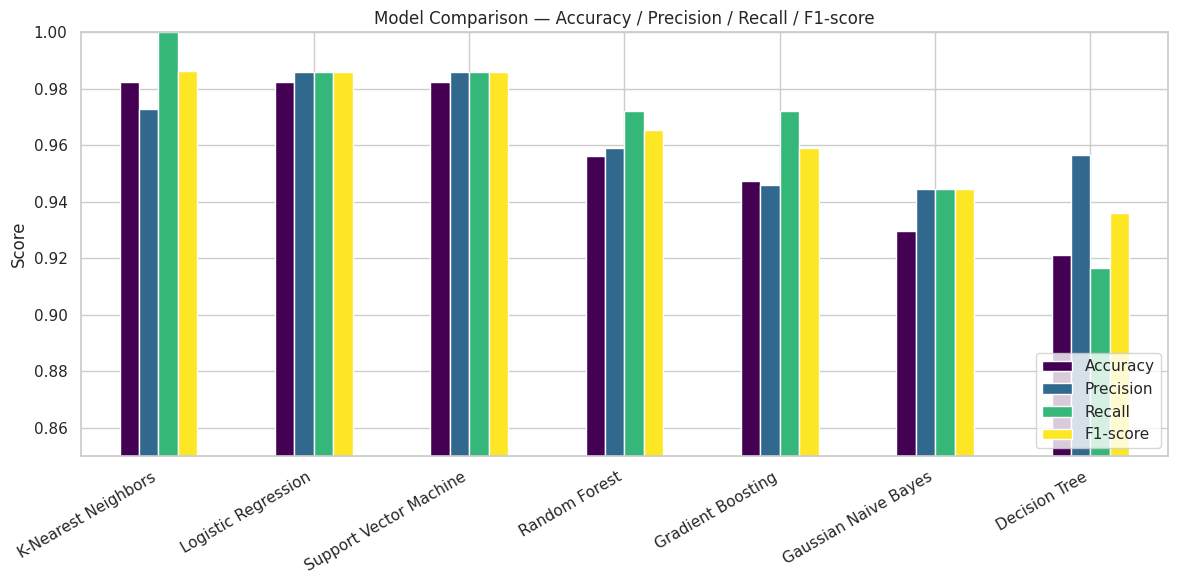

🏆 Best model by F1-score: K-Nearest Neighbors (0.9863)


In [22]:
results_df.plot(kind="bar", figsize=(12, 6), colormap="viridis")
plt.title("Model Comparison — Accuracy / Precision / Recall / F1-score")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_model_name = results_df["F1-score"].idxmax()
print(f"🏆 Best model by F1-score: {best_model_name} ({results_df.loc[best_model_name, 'F1-score']:.4f})")


### Cross-validation sanity check

A single train/test split can be noisy — 5-fold cross-validation on the training
set gives a more robust estimate of generalization performance for the top
model(s).

In [23]:
models_for_cv = {
    "Logistic Regression": log_reg,
    "KNN (best)": grid_knn.best_estimator_,
    "SVM (best)": grid_svm.best_estimator_,
    "Decision Tree (best)": grid_dt.best_estimator_,
    "Random Forest (best)": grid_rf.best_estimator_,
    "Gradient Boosting (best)": grid_gb.best_estimator_,
    "Naive Bayes": nb_model,
}

cv_summary = {}
for name, model in models_for_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="f1")
    cv_summary[name] = {"CV F1 mean": scores.mean(), "CV F1 std": scores.std()}

pd.DataFrame(cv_summary).T.sort_values("CV F1 mean", ascending=False).style.format("{:.4f}")


,CV F1 mean,CV F1 std
SVM (best),0.9844,0.0126
Logistic Regression,0.9843,0.0101
Gradient Boosting (best),0.9774,0.0115
KNN (best),0.9759,0.0191
Random Forest (best),0.9684,0.0151
Decision Tree (best),0.9518,0.0148
Naive Bayes,0.9459,0.0040


## 8. 🎯 Interview Cheat-Sheet — All Models at a Glance

| Model | Type | Error Minimization | Loss / Criterion | Needs Scaling? | Interpretable? |
|---|---|---|---|---|---|
| Logistic Regression | Linear, parametric | Gradient descent / lbfgs / Newton | Log-loss (cross-entropy) | Yes | High |
| KNN | Instance-based, lazy | None (no training-time optimization) | — (majority vote) | Yes | Medium |
| SVM | Max-margin, kernel method | Quadratic programming (SMO) | Hinge loss + L2 | Yes | Low–Medium |
| Decision Tree | Rule-based, greedy | Greedy recursive splitting (CART) | Gini impurity / entropy | No | High |
| Random Forest | Ensemble (bagging) | Greedy splits per tree + averaging | Gini impurity / entropy | No | Medium |
| Gradient Boosting | Ensemble (boosting) | Gradient descent in function space | Configurable (e.g. log-loss) | No | Low–Medium |
| Naive Bayes | Probabilistic, generative | Closed-form MLE (no iterations) | Likelihood | Not required | Medium |

**Most-asked interview questions this notebook prepares you for:**
1. *"What's the difference between bagging and boosting?"* → Random Forest
   (parallel, variance reduction) vs. Gradient Boosting (sequential, bias
   reduction via residual-fitting).
2. *"Which models require feature scaling and why?"* → Distance/gradient-based
   models (KNN, SVM, Logistic Regression) — because they use magnitudes/distances
   directly; tree-based models don't, since they only compare feature values via
   thresholds.
3. *"How does gradient descent work?"* → iteratively update parameters in the
   direction of the negative gradient of the loss function: `w := w - lr * ∇L(w)`,
   repeating until convergence.
4. *"Why not just use accuracy?"* → misleading under class imbalance; use
   precision/recall/F1, and pick the metric that matches business/clinical risk
   (e.g., prioritize recall when missing a positive case is costly).
5. *"What causes overfitting and how do you control it?"* → excessive model
   complexity (deep trees, high-degree kernels, too many boosting rounds) fitting
   noise; controlled via regularization (`C`, `max_depth`, `min_samples_split`,
   `n_estimators`/`learning_rate`, cross-validation, pruning).
6. *"What is the bias-variance trade-off?"* → simple models (Naive Bayes, shallow
   trees, high-k KNN) → high bias/low variance (underfit); complex models
   (deep trees, low-k KNN, high-degree SVM kernels) → low bias/high variance
   (overfit). Ensembles and regularization aim to balance both.

## 9. ✅ Conclusion

- All 7 models were trained and tuned on the same preprocessed data, enabling a
  fair, apples-to-apples comparison.
- Tree-free / margin-based models (SVM, Logistic Regression) and ensembles
  (Random Forest, Gradient Boosting) tend to perform strongly on this well-behaved,
  fairly linearly-separable dataset.
- The **best model by F1-score** is printed in Section 7 — in practice, model
  choice should also weigh interpretability, inference speed, and — in a medical
  setting — the relative cost of false negatives vs. false positives.
- Next steps for a production pipeline: k-fold nested cross-validation, feature
  selection / dimensionality reduction (e.g. PCA), calibrated probabilities, and
  external validation on new data.

---
*This notebook is intended as both a portfolio project and a study reference for
classification-model interview prep.*